## **Lasso Regularization (L1 Penalty)**

### **Topic Roadmap**

**1. Linear Lasso Regression (Coefficient Shrinkage)**
- **1.1 Dataset Generation**
- **1.2 Model Training and Evaluation**

**2. Polynomial Lasso Regression (Feature Selection)**
- **2.1 Nonlinear Dataset Generation**
- **2.2 High-Degree Polynomial Pipeline**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Lasso, LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

# Set consistent visual styling
sns.set_theme(style="whitegrid")

In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


### **1. Linear Lasso Regression (Coefficient Shrinkage)**

**What it does**

Applies an L1 penalty to the loss function, which forces the model to shrink the coefficients of less important features towards zero.

**Why it is used**

It helps prevent overfitting and performs automatic feature selection by effectively ignoring features that do not contribute significantly to the prediction.

In [4]:
# Generate a 1D regression dataset with noise
X_lin, y_lin = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

# Split into training and testing sets
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(


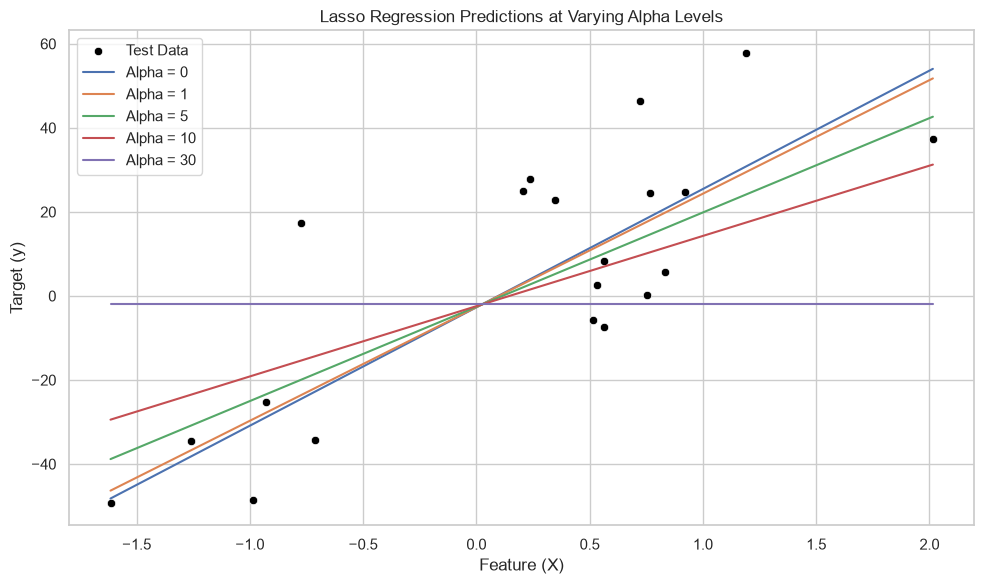

In [5]:
# Define penalty strengths to evaluate
alpha_values = [0, 1, 5, 10, 30]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_lin.ravel(), y=y_test_lin, color="black", label="Test Data")

for alpha in alpha_values:
    # Note: Alpha=0 is equivalent to standard Linear Regression
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train_lin, y_train_lin)
    
    # Generate predictions for the test set
    y_pred_lin = lasso_model.predict(X_test_lin)
    sns.lineplot(x=X_test_lin.ravel(), y=y_pred_lin, label=f'Alpha = {alpha}')

plt.title('Lasso Regression Predictions at Varying Alpha Levels')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.tight_layout()
plt.show()

### **Key Revision Notes**
- **L1 Penalty:** Lasso (Least Absolute Shrinkage and Selection Operator) applies a penalty proportional to the absolute value of the coefficients ($\alpha\sum|w_i|$).
- **Sparsity:** Unlike Ridge regularization, Lasso can shrink coefficients to exactly zero, effectively removing them from the model.
- **Alpha Impact:** Increasing the hyperparameter $\alpha$ increases the penalty. At very high values (e.g., 30), the slope is severely penalized, resulting in an underfitted, flatter line.

### **2. Polynomial Lasso Regression (Feature Selection)**

**What it does**

Combines polynomial feature expansion with Lasso regularization to model nonlinear relationships while keeping the model sparse.

**Why it is used**

High-degree polynomials naturally create many highly correlated features, leading to severe overfitting. Lasso automatically identifies and retains only the relevant polynomial degrees, zeroing out the rest.

In [6]:
# Generate a nonlinear (quadratic) dataset with random noise
np.random.seed(42)
n_samples = 100
X_poly = 5 * np.random.rand(n_samples, 1) - 2
y_poly = 0.7 * X_poly ** 2 - 2 * X_poly + 3 + np.random.randn(n_samples, 1)

C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.726e+01, tolerance: 7.746e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV i

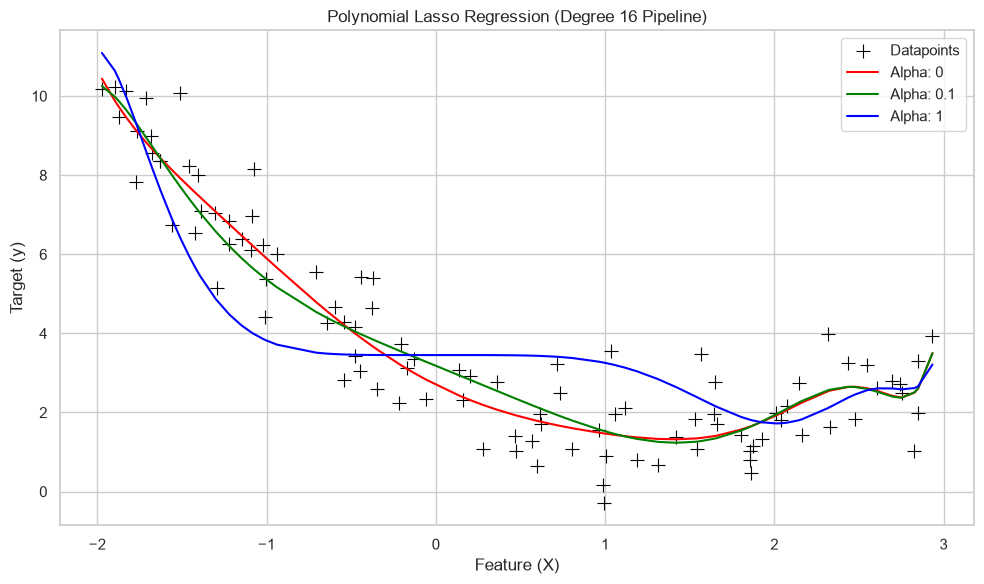

In [7]:
alphas_poly = [0, 0.1, 1]
color_palette = ['red', 'green', 'blue']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_poly.ravel(), y=y_poly.ravel(), color='black', marker='+', s=100, label='Datapoints')

# Sort X values to ensure line plots render smoothly
X_plot_sorted = np.sort(X_poly, axis=0)

for alpha, color in zip(alphas_poly, color_palette):
    # Create a pipeline: Expand to 16-degree polynomial, then apply Lasso
    poly_lasso_pipe = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha, max_iter=10000))  # Increased max_iter for convergence stability
    ])
    
    poly_lasso_pipe.fit(X_poly, y_poly)
    y_plot_pred = poly_lasso_pipe.predict(X_plot_sorted)
    
    sns.lineplot(x=X_plot_sorted.ravel(), y=y_plot_pred, color=color, label=f'Alpha: {alpha}')

plt.title('Polynomial Lasso Regression (Degree 16 Pipeline)')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.tight_layout()
plt.show()

### **Key Revision Notes**
- **Overfitting Control:** A polynomial of degree 16 naturally overfits the data by capturing random noise.
- **Alpha = 0:** No penalty is applied. The model attempts to fit a complex 16-degree polynomial, leading to high variance and chaotic predictions.
- **Alpha > 0:** The L1 penalty forces the coefficients of the irrelevant high-degree polynomial features to exactly zero. This smooths the curve and correctly approximates the true underlying quadratic relationship.